# Live 2D Try-On Experiments

Run a continuous webcam preview loop using the stronger 2D live baseline.

Controls:
- `q`: quit the live preview
- the notebook refreshes recommendations every few frames and keeps a stable top asset between refreshes


In [1]:
from pathlib import Path
import sys

import cv2
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'backend').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate project root.')

PROJECT_ROOT = find_project_root()
BACKEND_ROOT = PROJECT_ROOT / 'backend'
if str(BACKEND_ROOT) not in sys.path:
    sys.path.append(str(BACKEND_ROOT))

from app.core.asset_bank import asset_bank_summary
from app.core.live_tryon import LiveTryOnState, process_live_frame


In [2]:
TARGET_GENDER = 'male'
TOP_K = 3
CAMERA_INDEX = 0
RECOMMEND_EVERY_N_FRAMES = 6
SEGMENT_EVERY_N_FRAMES = 5
MAX_FRAMES = 180
DISPLAY_WIDTH = 1280
SAVE_DIAGNOSTIC_FRAMES = True
DIAGNOSTIC_SAVE_EVERY_N_FRAMES = 12
MAX_DIAGNOSTIC_FRAMES = 16
DIAGNOSTIC_FRAME_DIR = PROJECT_ROOT / 'backend' / 'outputs' / 'live_segmentation_eval' / 'inputs'
DIAGNOSTIC_FRAME_DIR.mkdir(parents=True, exist_ok=True)

bank = asset_bank_summary()
print('Active asset bank:', bank['metadata_dir'])
print('Asset count:', bank['asset_count'])


Active asset bank: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\data\processed\celeba_full_hair_assets\reviewed_render_safe\kept_assets.jsonl
Asset count: 83


In [3]:
capture = cv2.VideoCapture(CAMERA_INDEX)
if not capture.isOpened():
    raise RuntimeError(f'Could not open webcam index {CAMERA_INDEX}.')

state = LiveTryOnState()
history = []
last_result = None
frame_index = 0
saved_diagnostic_frames = 0

print('Starting continuous live preview... press q in the window to stop.')

try:
    while frame_index < MAX_FRAMES:
        ok, frame = capture.read()
        if not ok:
            break

        frame_index += 1
        refresh_recommendations = frame_index % RECOMMEND_EVERY_N_FRAMES == 0 or last_result is None
        refresh_segmentation = frame_index % SEGMENT_EVERY_N_FRAMES == 0 or last_result is None
        result = process_live_frame(
            frame,
            target_gender=TARGET_GENDER,
            top_k=TOP_K,
            state=state,
            refresh_recommendations=refresh_recommendations,
            refresh_segmentation=refresh_segmentation,
        )
        result['frame_index'] = frame_index
        last_result = result

        top_recommendation = result['recommendations'][0] if result['recommendations'] else None

        if (
            SAVE_DIAGNOSTIC_FRAMES
            and saved_diagnostic_frames < MAX_DIAGNOSTIC_FRAMES
            and frame_index % DIAGNOSTIC_SAVE_EVERY_N_FRAMES == 0
        ):
            diagnostic_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            diagnostic_image = Path(DIAGNOSTIC_FRAME_DIR) / f'live_frame_{frame_index:04d}_{result.get("support_reason", "unknown")}.png'
            cv2.imwrite(str(diagnostic_image), cv2.cvtColor(diagnostic_rgb, cv2.COLOR_RGB2BGR))
            saved_diagnostic_frames += 1
        history.append(
            {
                'frame_index': frame_index,
                'face_detected': result['face_detected'],
                'stable_asset_id': result['stable_asset_id'],
                'top_asset_id': top_recommendation.asset_id if top_recommendation else None,
                'top_score': top_recommendation.score if top_recommendation else None,
                'style_family': top_recommendation.normalized_attributes.style_family if top_recommendation else None,
                'mask_status': result.get('mask_status', 'unknown'),
                'frame_supported': result.get('frame_supported', False),
                'support_reason': result.get('support_reason', 'unknown'),
                'used_mask_fallback': result.get('used_mask_fallback', False),
                'used_preview_grace': result.get('used_preview_grace', False),
                'refreshed': refresh_recommendations,
                'segmentation_refreshed': refresh_segmentation,
            }
        )

        if result['preview_image'] is not None:
            preview_rgb = np.asarray(result['preview_image'].convert('RGB'))
            display_frame = cv2.cvtColor(preview_rgb, cv2.COLOR_RGB2BGR)
        else:
            display_frame = frame.copy()

        if display_frame.shape[1] > DISPLAY_WIDTH:
            scale = DISPLAY_WIDTH / display_frame.shape[1]
            display_frame = cv2.resize(
                display_frame,
                (DISPLAY_WIDTH, int(display_frame.shape[0] * scale)),
                interpolation=cv2.INTER_AREA,
            )

        status = 'face detected' if result['face_detected'] else 'no face'
        stable_text = result['stable_asset_id'] or 'none'
        mask_text = result.get('mask_status', 'unknown')
        support_text = result.get('support_reason', 'unknown')
        cv2.putText(
            display_frame,
            f'frame {frame_index} | {status} | support: {support_text} | mask: {mask_text} | stable: {stable_text}',
            (16, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (30, 230, 30),
            2,
            cv2.LINE_AA,
        )

        if top_recommendation is not None:
            cv2.putText(
                display_frame,
                f'top: {top_recommendation.asset_id} | score={top_recommendation.score:.3f}',
                (16, 60),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                (30, 230, 30),
                2,
                cv2.LINE_AA,
            )

        cv2.imshow('Live 2D Try-On Preview', display_frame)
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
finally:
    capture.release()
    cv2.destroyAllWindows()

print('Processed frames:', frame_index)
print('Saved diagnostic frames:', saved_diagnostic_frames)
print('Diagnostic frame dir:', DIAGNOSTIC_FRAME_DIR)


Starting continuous live preview... press q in the window to stop.
Processed frames: 30
Saved diagnostic frames: 2
Diagnostic frame dir: D:\Projects\Personal Projects\Hairstyle Recommender Live Tryon\backend\outputs\live_segmentation_eval\inputs


In [4]:
history_df = pd.DataFrame(history)
history_df.tail(20)


,frame_index,face_detected,stable_asset_id,top_asset_id,top_score,style_family,mask_status,frame_supported,support_reason,used_mask_fallback,used_preview_grace,refreshed,segmentation_refreshed
10,11,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
11,12,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,True,False
12,13,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
13,14,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
14,15,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,fresh,True,supported,False,False,False,True
15,16,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
16,17,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
17,18,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,True,False
18,19,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,held,True,supported,True,False,False,False
19,20,True,celeba_full_hair_000082,celeba_full_hair_000082,0.96,pompadour,fresh,True,supported,False,False,False,True


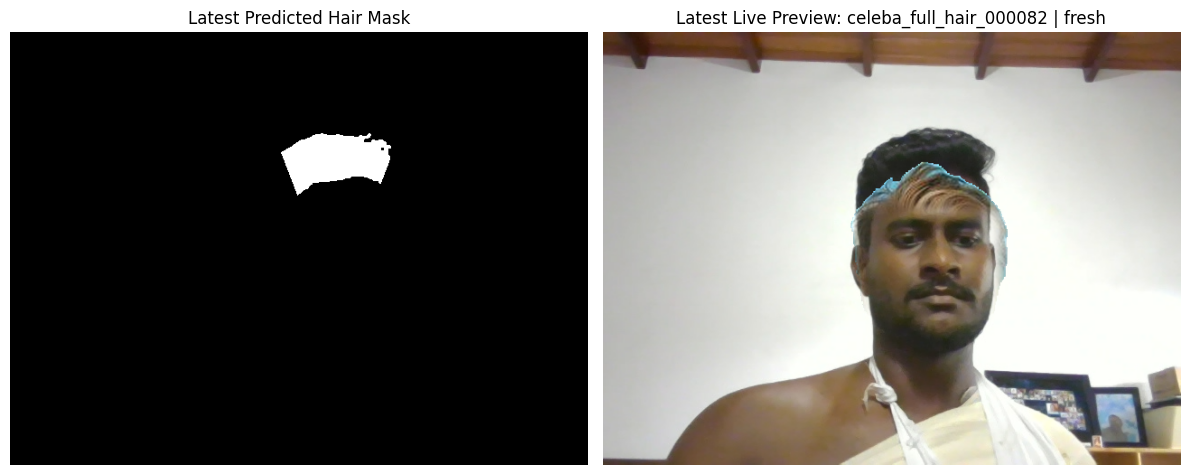

Face attributes: {'face_shape': 'unknown', 'forehead': 'medium', 'jaw': 'soft', 'cheekbone': 'medium', 'face_width': 'narrow'}
Stable asset: celeba_full_hair_000082
Support reason: supported
Frame supported: True
Mask status: fresh
Used mask fallback: False
Used preview grace: False
Top style family: pompadour
Top score: 0.96


In [5]:
if last_result is None:
    raise RuntimeError('No live result was collected.')

analysis = last_result['analysis']
top_recommendation = last_result['recommendations'][0] if last_result['recommendations'] else None

figure, axes = plt.subplots(1, 2, figsize=(12, 5))
if last_result['subject_hair_mask'] is not None:
    axes[0].imshow(np.asarray(last_result['subject_hair_mask']), cmap='gray')
else:
    axes[0].text(0.5, 0.5, 'No mask', ha='center', va='center')
axes[0].set_title('Latest Predicted Hair Mask')
axes[0].axis('off')

if last_result['preview_image'] is not None:
    axes[1].imshow(last_result['preview_image'].convert('RGB'))
else:
    axes[1].text(0.5, 0.5, f"No preview ({last_result.get('mask_status', 'unknown')})", ha='center', va='center')
axes[1].set_title(f"Latest Live Preview: {last_result['stable_asset_id']} | {last_result.get('mask_status', 'unknown')}")
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Face attributes:', analysis.face_attributes)
print('Stable asset:', last_result['stable_asset_id'])
print('Support reason:', last_result.get('support_reason', 'unknown'))
print('Frame supported:', last_result.get('frame_supported', False))
print('Mask status:', last_result.get('mask_status', 'unknown'))
print('Used mask fallback:', last_result.get('used_mask_fallback', False))
print('Used preview grace:', last_result.get('used_preview_grace', False))
if top_recommendation is not None:
    print('Top style family:', top_recommendation.normalized_attributes.style_family)
    print('Top score:', top_recommendation.score)


In [6]:
top_rows = []
for item in last_result['recommendations']:
    top_rows.append(
        {
            'asset_id': item.asset_id,
            'score': item.score,
            'gender_suitability': item.gender_suitability,
            'length': item.normalized_attributes.length,
            'curl': item.normalized_attributes.curl,
            'volume': item.normalized_attributes.volume,
            'side_hair': item.normalized_attributes.side_hair,
            'style_family': item.normalized_attributes.style_family,
            'reason': item.reason,
        }
    )

display(pd.DataFrame(top_rows))


,asset_id,score,gender_suitability,length,curl,volume,side_hair,style_family,reason
0,celeba_full_hair_000082,0.9600,male,medium,wavy,high,exposed,pompadour,pompadour is a safe style match while face geo...
1,celeba_full_hair_000111,0.9450,male,medium,wavy,medium,exposed,pompadour,pompadour is a safe style match while face geo...
2,celeba_full_hair_000068,0.7671,male,medium,straight,medium,exposed,side_part,side part is a safe style match while face geo...
